In [284]:
import scipy
import seaborn
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1

In [166]:
alpha = 5
beta = 2
n = 10
k = 8
sigma = 0.2

a) Proposal Distribution

In [167]:
def propose_jump(pi, sigma, size = 1):
    result = scipy.stats.norm.rvs(
        loc = pi, # mean
        scale = sigma, # standard deviation
        size = size
    )
    return result if size > 1 else result.item()


def normalize(values: list):
    array = np.array(values, dtype = float)
    return (array - array.min()) / (array.max() - array.min())

b) Random walk

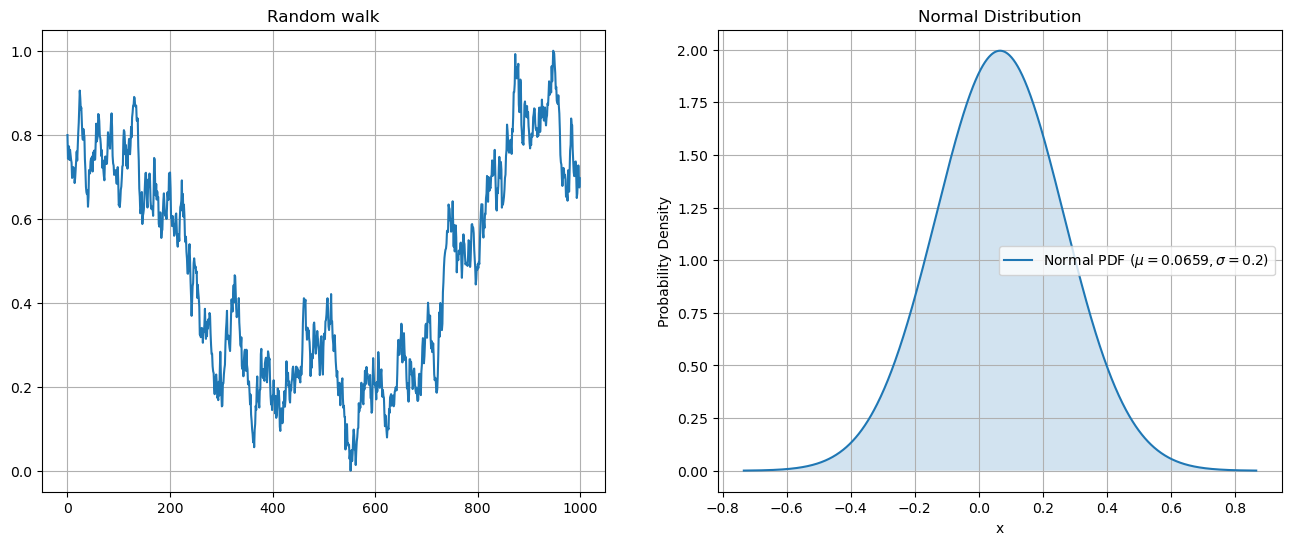

In [173]:
def plot_normal_distribution(ax, mean, sigma):
    # Generate x values around the mean
    x = np.linspace(mean - 4 * sigma, mean + 4 * sigma, 1000)

    # Compute the PDF
    y = scipy.stats.norm.pdf(x, loc = mean, scale = sigma)
    ax.plot(x, y, label=f'Normal PDF ($\mu={mean:.4f}, \sigma={sigma}$)')
    ax.fill_between(x, y, alpha=0.2)
    ax.set_title("Normal Distribution")
    ax.set_xlabel("x")
    ax.set_ylabel("Probability Density")
    ax.grid(True)
    ax.legend()

start = np.random.rand()

steps = []
for i in range(1000):
    pi = start
    if i > 0:
        pi = steps[i - 1]

    steps.append(propose_jump(pi, sigma))

walk = normalize(steps)

fig = plt.figure(figsize = (16, 6))

ax = fig.add_subplot(1, 2, 1)
ax.set_title('Random walk')
ax.grid(True)
ax.plot(walk)

ax = fig.add_subplot(1, 2, 2)
plot_normal_distribution(ax, start, sigma)


c) Jump decision

In [169]:
def acceptance_propability(pi, pi2, alpha, beta, n, k):
    numerator = scipy.stats.beta.pdf(x = pi2, a = alpha, b = beta) * scipy.stats.binom.pmf(k = k, n = n, p = pi2)
    denominator = scipy.stats.beta.pdf(x = pi, a = alpha, b = beta) * scipy.stats.binom.pmf(k = k, n = n, p = pi)
    return min(1, numerator / denominator)

def decide(pi, pi2, alpha, beta, n, k):
    if pi2 > 1 or pi2 < 0:
        return pi

    p = np.random.rand()
    acceptance_p = acceptance_propability(pi, pi2, alpha, beta, n, k)

    if p <= acceptance_p:
        return pi2
    else:
        return pi

d) Single-chain Metropolis algorithm

In [274]:
def metropolis_chain(n_steps, alpha, beta, n, k, sigma):
    chain = np.zeros(n_steps)
    pi = np.random.rand()

    for i in range(n_steps):
        pi2 = propose_jump(pi, sigma)
        pi = decide(pi, pi2, alpha, beta, n, k)
        chain[i] = pi

    return np.array(chain)


def plot_trace(pi, title: str = "Trace plot of π", ax: plt.Axes = None):
    ax = plt.subplots(figsize=(10, 4))[1] if ax is None else ax

    if pi.ndim == 2:
        for i, chain in enumerate(pi):
            ax.plot(chain, alpha=0.7, label=f'Chain {i+1}')
        ax.legend()
    else:
        ax.plot(pi)

    ax.set_title(title)
    ax.set_xlabel("step")
    ax.set_ylabel("π")
    ax.grid(True)

e) Verification: Hyperparameter tuning

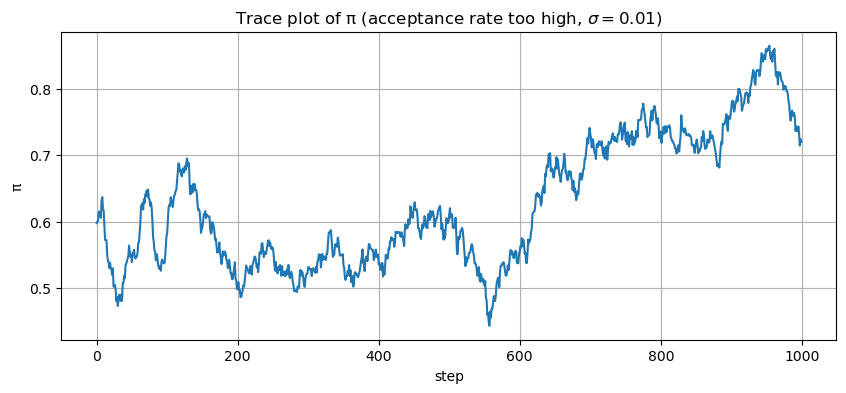

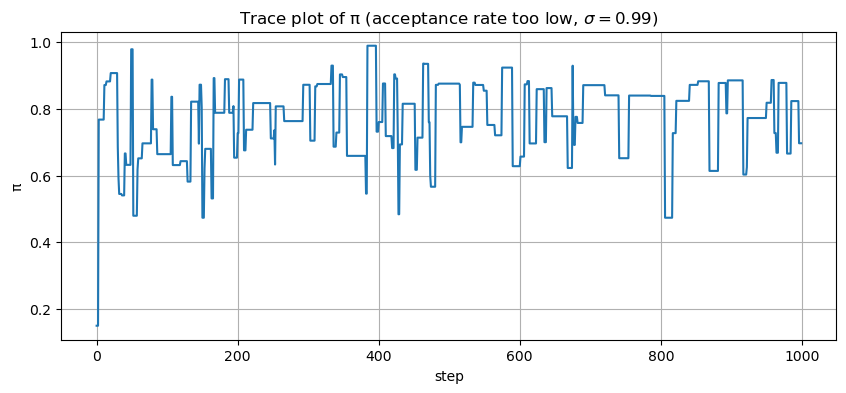

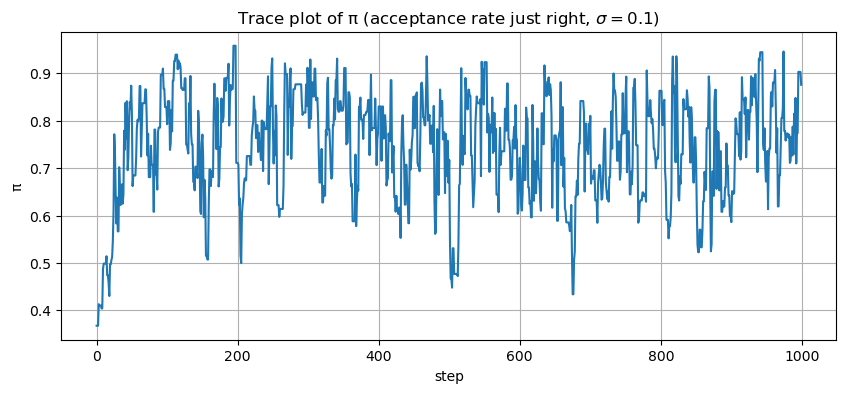

In [278]:
plot_trace(
    metropolis_chain(
        n_steps = 1000,
        alpha = alpha,
        beta = beta,
        n = n,
        k = k,
        sigma = 0.01
    ),
    title = "Trace plot of π (acceptance rate too high, $\sigma = 0.01$)"
)

plot_trace(
    metropolis_chain(
        n_steps = 1000,
        alpha = alpha,
        beta = beta,
        n = n,
        k = k,
        sigma = 0.99
    ),
    title = "Trace plot of π (acceptance rate too low, $\sigma = 0.99$)"
)

plot_trace(
    metropolis_chain(
        n_steps = 1000,
        alpha = alpha,
        beta = beta,
        n = n,
        k = k,
        sigma = 0.1
    ),
    title = "Trace plot of π (acceptance rate just right, $\sigma = 0.1$)"
)


e) Verification: Visualize distribution

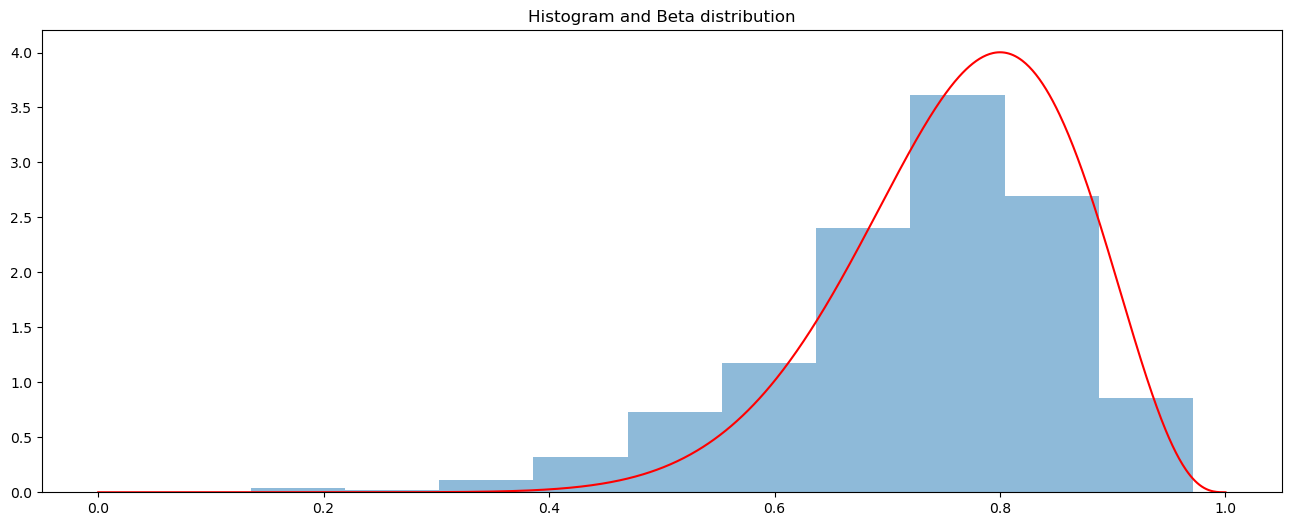

In [249]:
chain = metropolis_chain(
    n_steps = 1000,
    alpha = alpha,
    beta = beta,
    n = n,
    k = k,
    sigma = 0.1
)

def plot_hist_and_beta_distribution(chain, alpha, beta, n, k, title: str = "Histogram and Beta distribution", ax: plt.Axes = None):
    ax = plt.subplots(figsize=(16, 6))[1] if ax is None else ax
    ax.hist(chain, density = True, alpha = 0.5)

    beta_distribution_samples = np.linspace(0, 1, 1000)
    ax.plot(beta_distribution_samples, scipy.stats.beta.pdf(beta_distribution_samples, alpha + k, beta + n - k), color = 'red')
    ax.set_title(title)

plot_hist_and_beta_distribution(chain, alpha, beta, n, k)

f) Playing around

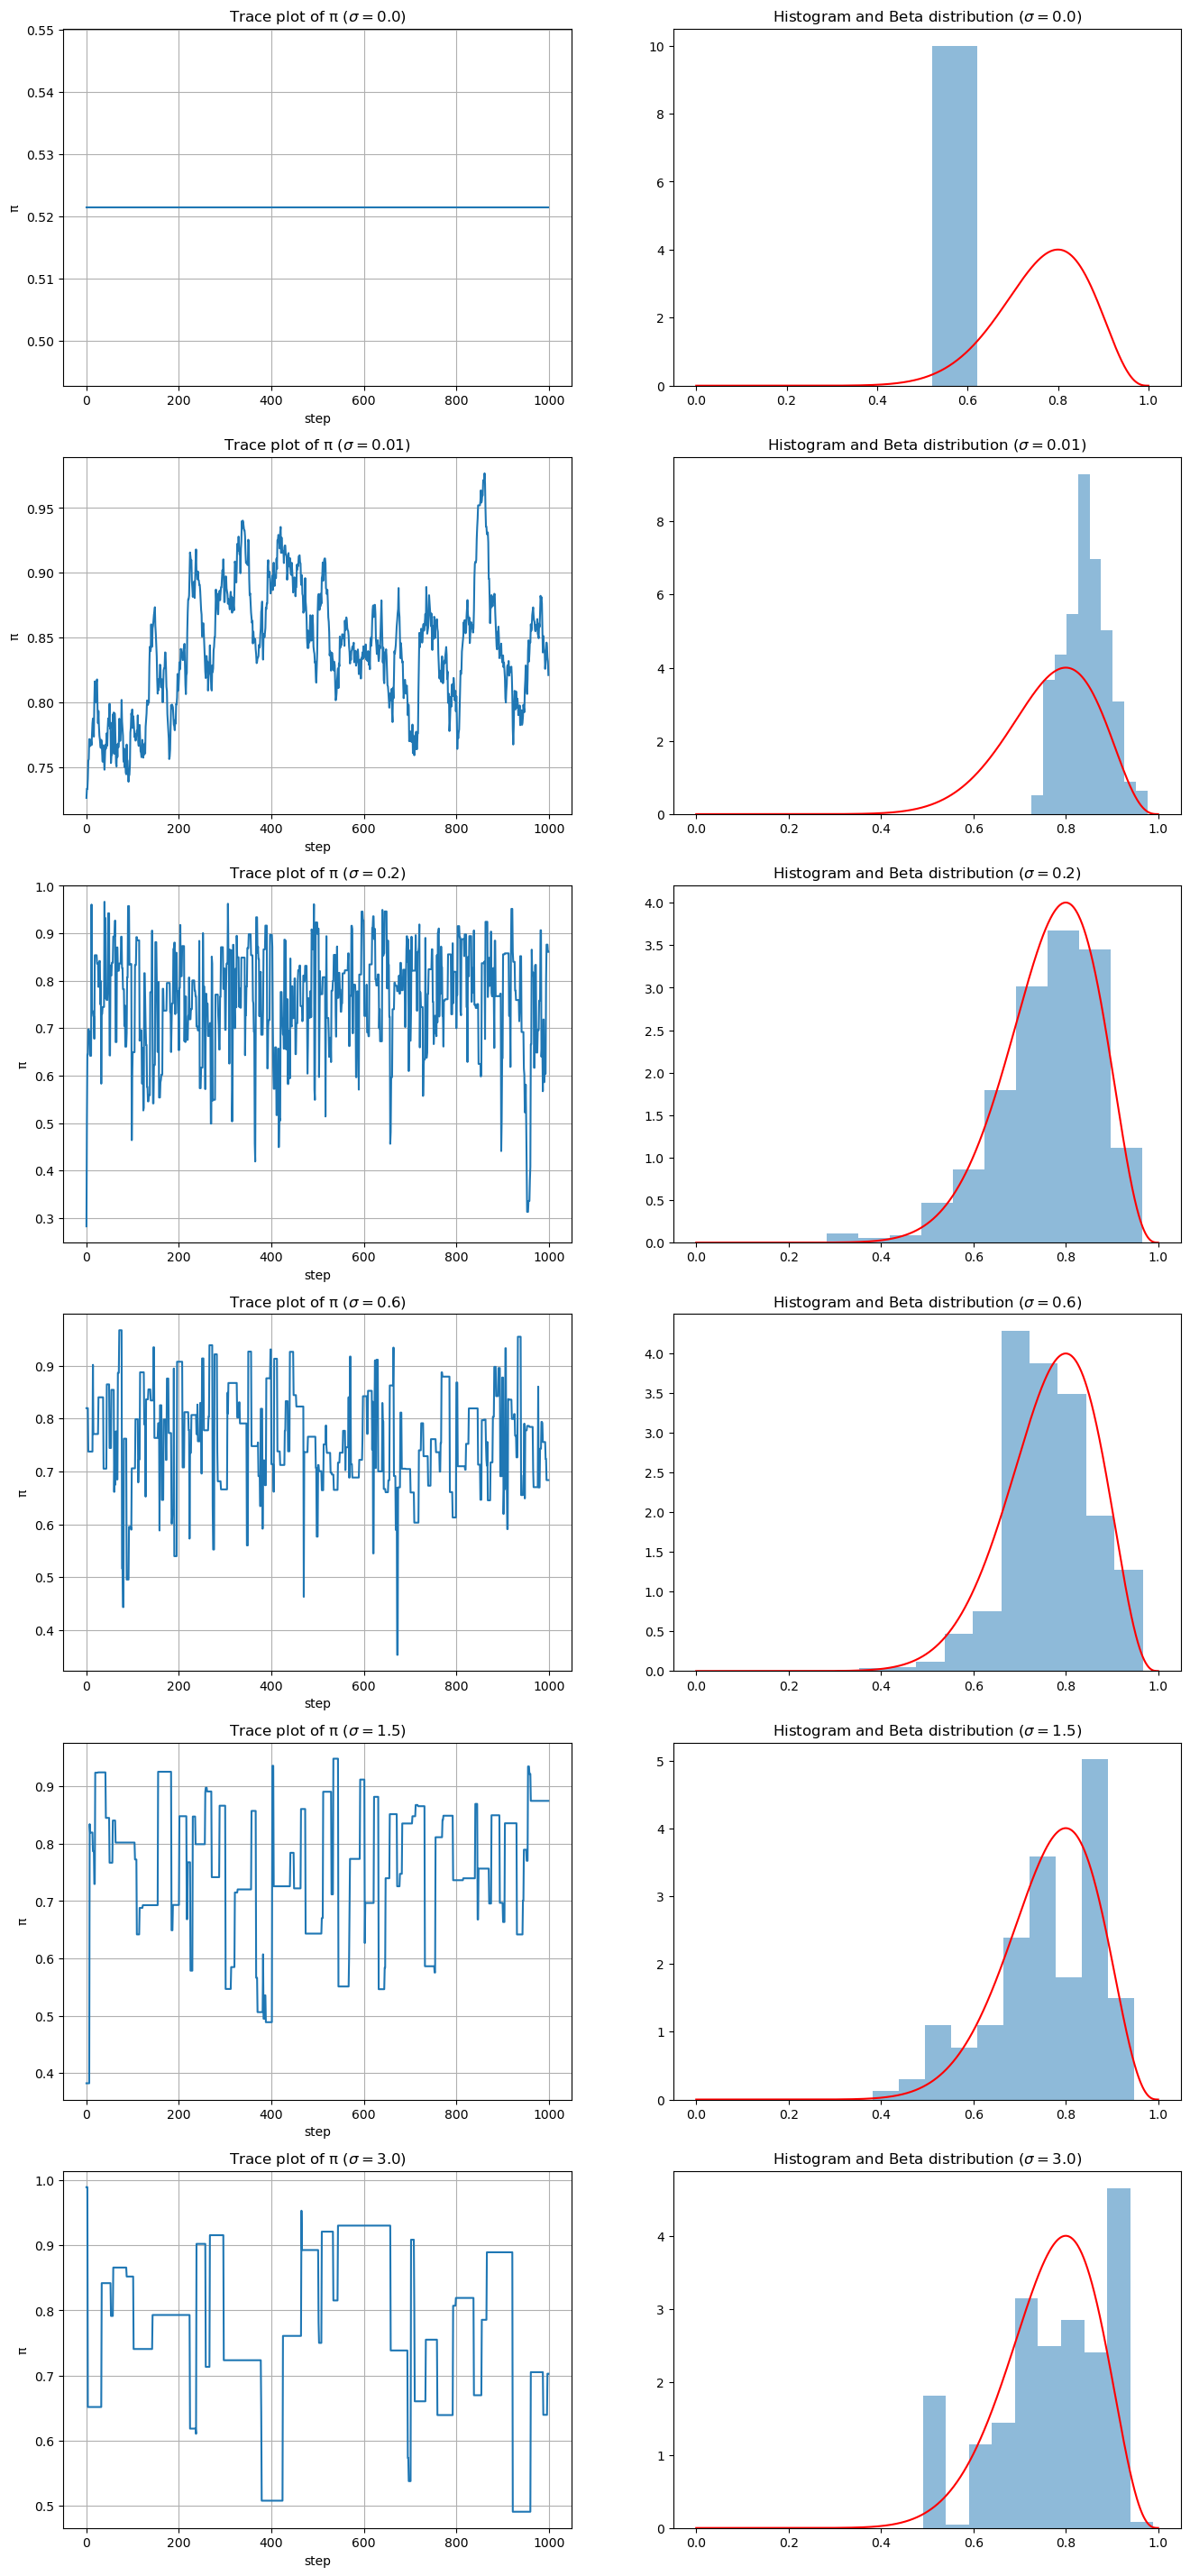

In [269]:
sigmas = [0.0, 0.01, 0.2, 0.6, 1.5, 3.0]

plot_nrows = len(sigmas)
fig = plt.figure(figsize = (16, 6 * plot_nrows))

for i, sigma in enumerate(sigmas):
    chain = metropolis_chain(
            n_steps = 1000,
            alpha = alpha,
            beta = beta,
            n = n,
            k = k,
            sigma = sigma
        )

    ax = fig.add_subplot(plot_nrows, 2, 2*i + 1)
    plot_trace(chain, title = f"Trace plot of π ($\sigma = {sigma}$)", ax = ax)

    ax = fig.add_subplot(plot_nrows, 2, 2*i + 2)
    plot_hist_and_beta_distribution(chain, alpha, beta, n, k, title = f"Histogram and Beta distribution ($\sigma = {sigma}$)", ax = ax)


# Exercise 2

a) Multiple Chains

In [270]:
def metropolis(n_chains, n_steps, alpha, beta, n, k, sigma):
    chains = np.zeros((n_chains, n_steps))
    for i in range(n_chains):
        chains[i] = metropolis_chain(n_steps, alpha, beta, n, k, sigma)
    return chains

b) Trace plots

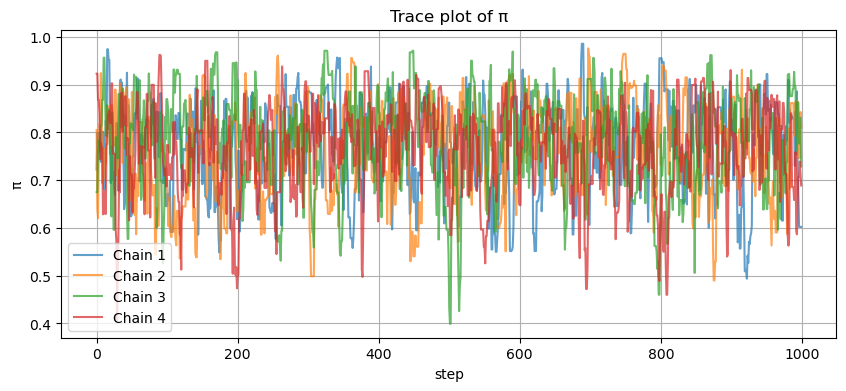

In [305]:
n_chains = 4
sigma = 0.1

chains = metropolis(n_chains, 1000, alpha, beta, n, k, sigma)
plot_trace(chains)

Things look good: The 4 chains mix nicely.

Text(0.5, 1.0, 'Kernel Density Estimate of π')

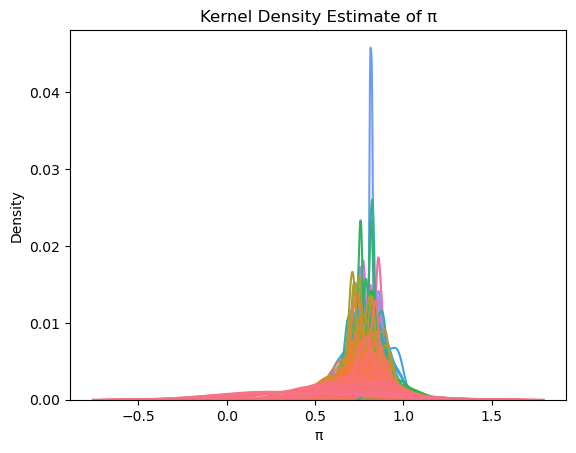

In [293]:
seaborn.kdeplot(chains, legend = False)
plt.xlabel("π")
plt.ylabel("Density")
plt.title("Kernel Density Estimate of π")

The kernel density estimate shows a surface which seems to be rather similar to the distribution we are looking for.

**For too small sigma:**

Values tend to stay in the same area and don't really mix - which means we don't receive a meaningful distriution.

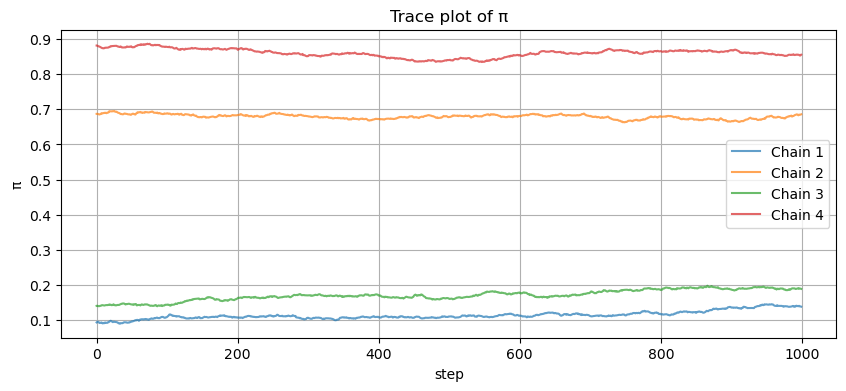

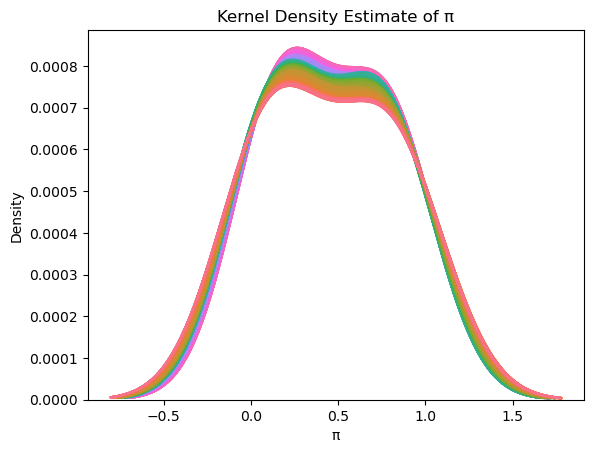

In [315]:
n_chains = 4
sigma = 0.001

chains = metropolis(n_chains, 1000, alpha, beta, n, k, sigma)
plot_trace(chains)
plt.show()

seaborn.kdeplot(chains, legend = False)
plt.xlabel("π")
plt.ylabel("Density")
plt.title("Kernel Density Estimate of π")
plt.show()

**For too large sigma:**

the different chains don't mix are reduced to just a few different values. So we don't really receive a meaningful distribution.

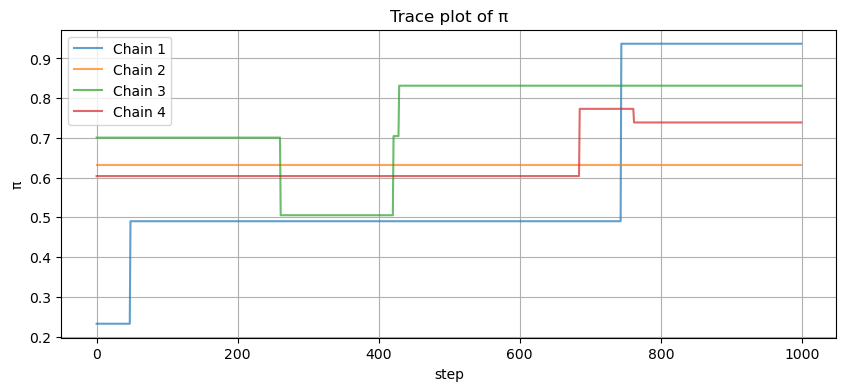

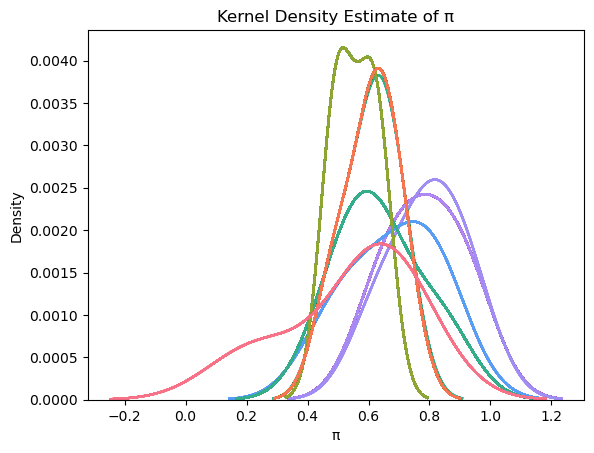

In [316]:
n_chains = 4
sigma = 100

chains = metropolis(n_chains, 1000, alpha, beta, n, k, sigma)
plot_trace(chains)
plt.show()

seaborn.kdeplot(chains, legend = False)
plt.xlabel("π")
plt.ylabel("Density")
plt.title("Kernel Density Estimate of π")
plt.show()

d) $\hat{R}$

In [332]:
def compute_rhat(chains):
    variance_total = np.var(chains, ddof = 1)
    variance_per_chain = np.var(chains, axis = 1, ddof = 1)
    mean_variance_per_chain = np.mean(variance_per_chain)

    return np.sqrt(variance_total / mean_variance_per_chain)

In [338]:
n_chains = 4
sigma = 0.1
chains = metropolis(n_chains, 1000, alpha, beta, n, k, sigma)

compute_rhat(chains)

np.float64(1.0010289707363826)

**$\hat{R}$ for too small sigma:**

In [346]:
sigmas = [0.001, 0.01]

for sigma in sigmas:
    rhat = compute_rhat(metropolis(4, 1000, alpha, beta, n, k, sigma))
    print(f"sigma = {sigma}, Rhat = {rhat:.4f}")

sigma = 0.001, Rhat = 17.2556
sigma = 0.01, Rhat = 1.2217


**$\hat{R}$ for too large sigma:**

In [345]:
sigmas = [0.5, 1.0, 100]

for sigma in sigmas:
    rhat = compute_rhat(metropolis(4, 1000, alpha, beta, n, k, sigma))
    print(f"sigma = {sigma}, Rhat = {rhat:.4f}")

sigma = 0.5, Rhat = 1.0010
sigma = 1.0, Rhat = 1.0063
sigma = 100, Rhat = 1.7476


$\hat{R}$ doesn't seem to be enough to distuingish good from bad chains.

e) Burn-in phase

The values from the burn-in phase are not relevant for the beta-binominal problem. Given we sample enough data points, the burn in phase will be neglectable. However, if we don't sample as many data points, we need to be aware that the burn-in phase might skew our resulting distribution and we might consider removing the first n samples.

# Exercise 3


a) Reproduce the results from previous exercise with PyMC